# Experiment 8 — repeated-CV robustness

**Question.** Do the decisions that promoted E5 over E4 and E6 over E5 survive alternative validation-fold assignments?

**Held constant.** The Experiment 4 feature set, preprocessing, model randomness (`random_state=42`), historical hyperparameters, deployed boosting-round counts, and predeclared blend weights. **Changed.** Only the shuffled five-fold `StratifiedKFold` seed: 7, 21, 84, 123, and 2026.

**Promotion criterion.** This is confirmation, not tuning. E6 remains champion unless repeated validation gives meaningful evidence against it; no submission is created.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
REPORTS = ROOT / "reports"
required = [
    "repeated_cv_seed_results.csv", "repeated_cv_summary.csv",
    "repeated_cv_comparisons.csv", "repeated_cv_blend_grid.csv",
    "repeated_cv_analysis.json",
]
missing = [name for name in required if not (REPORTS / name).exists()]
assert not missing, f"Missing saved reports: {missing}"
results = pd.read_csv(REPORTS / "repeated_cv_seed_results.csv")
summary = pd.read_csv(REPORTS / "repeated_cv_summary.csv")
comparisons = pd.read_csv(REPORTS / "repeated_cv_comparisons.csv")
grid = pd.read_csv(REPORTS / "repeated_cv_blend_grid.csv")
analysis = json.loads((REPORTS / "repeated_cv_analysis.json").read_text())
print("Loaded compact Experiment 8 reports; no models are trained in this notebook.")

Loaded compact Experiment 8 reports; no models are trained in this notebook.


## Per-seed results

Each displayed AUC is calculated from a complete OOF vector for that seed. The five seeds—not the 25 folds—are the independent units used below.

configuration,E4,E5,E6
fold_seed,,,
7,0.961217,0.963905,0.964237
21,0.961308,0.963906,0.964224
84,0.961337,0.963892,0.964213
123,0.961284,0.963889,0.964213
2026,0.961288,0.963891,0.964232


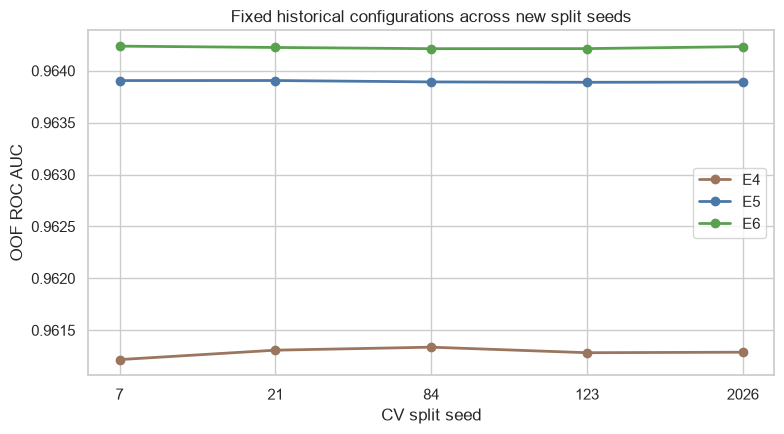

In [2]:
selected = (results.query("result_type == 'blend' and model.str.contains('selected blend')", engine="python")
            .pivot(index="fold_seed", columns="configuration", values="oof_auc")
            .rename(columns=str.upper))
display(selected.style.format("{:.6f}"))

fig, ax = plt.subplots(figsize=(8, 4.5))
for column, color in zip(["E4", "E5", "E6"], ["#9C755F", "#4C78A8", "#59A14F"]):
    ax.plot(selected.index.astype(str), selected[column], marker="o", linewidth=2, label=column, color=color)
ax.set(title="Fixed historical configurations across new split seeds", xlabel="CV split seed", ylabel="OOF ROC AUC")
ax.legend()
plt.tight_layout()
plt.show()

The absolute score moves slightly with fold assignment, but the ordering does not: E5 beats E4 and E6 beats E5 on every added seed. E6's absolute AUC averages about 0.964224 with much less between-seed variation than the size of its gain over E5.

In [3]:
selected_summary = summary.query("model.str.contains('selected blend')", engine="python")[
    ["configuration", "mean_seed_auc", "median_seed_auc", "std_seed_auc", "min_seed_auc", "max_seed_auc"]
]
display(selected_summary.style.format({column: "{:.6f}" for column in selected_summary.columns if column != "configuration"}))

component_summary = summary.query("result_type == 'component'")[
    ["configuration", "model", "mean_seed_auc", "std_seed_auc", "total_fit_seconds", "total_predict_seconds"]
]
display(component_summary.style.format({"mean_seed_auc": "{:.6f}", "std_seed_auc": "{:.6f}", "total_fit_seconds": "{:.1f}", "total_predict_seconds": "{:.1f}"}))

,configuration,mean_seed_auc,median_seed_auc,std_seed_auc,min_seed_auc,max_seed_auc
0,e4,0.961287,0.961288,0.000044,0.961217,0.961337
3,e5,0.963897,0.963892,0.000008,0.963889,0.963906
9,e6,0.964224,0.964224,0.000011,0.964213,0.964237


,configuration,model,mean_seed_auc,std_seed_auc,total_fit_seconds,total_predict_seconds
1,e4,LightGBM,0.960815,0.000042,62.3,7.0
2,e4,XGBoost,0.960818,0.000031,56.3,1.8
4,e5,LightGBM,0.963209,0.000026,378.6,25.6
5,e5,XGBoost,0.963615,0.000035,248.0,8.4
10,e6,LightGBM,0.963409,0.000014,1184.5,91.6
11,e6,XGBoost,0.963878,0.000017,916.6,33.6


## Paired decision checks

Pairing by seed removes much of the fold-assignment noise. The table reports the exact seed-level differences; the compact JSON adds both a paired t interval and a 10,000-resample bootstrap over the five seed differences.

In [4]:
display(comparisons.style.format({column: "{:+.6f}" for column in comparisons.columns if column != "fold_seed"}))

paired_rows = []
for name, values in analysis["selected_blend_comparisons"].items():
    paired_rows.append({
        "comparison": name, "mean_gain": values["mean_difference"],
        "median_gain": values["median_difference"],
        "bootstrap_95_low": values["seed_bootstrap_ci_95_lower"],
        "bootstrap_95_high": values["seed_bootstrap_ci_95_upper"],
        "wins/ties/losses": f"{values['wins']}/{values['ties']}/{values['losses']}",
    })
paired = pd.DataFrame(paired_rows)
display(paired.style.format({column: "{:+.6f}" for column in ["mean_gain", "median_gain", "bootstrap_95_low", "bootstrap_95_high"]}))

,fold_seed,e5_minus_e4,e6_minus_e5,e6_minus_e4
0,7,+0.002688,+0.000332,+0.003020
1,21,+0.002598,+0.000319,+0.002916
2,84,+0.002556,+0.000320,+0.002876
3,123,+0.002605,+0.000324,+0.002930
4,2026,+0.002603,+0.000341,+0.002944


,comparison,mean_gain,median_gain,bootstrap_95_low,bootstrap_95_high,wins/ties/losses
0,e5_minus_e4,+0.002610,+0.002603,+0.002575,+0.002653,5/0/0
1,e6_minus_e5,+0.000327,+0.000324,+0.000320,+0.000335,5/0/0
2,e6_minus_e4,+0.002937,+0.002930,+0.002900,+0.002984,5/0/0


E5−E4 averages **+0.002610** AUC and E6−E5 averages **+0.000327**. Both comparisons are 5/0/0 wins/ties/losses, with positive seed-bootstrap intervals. The original seed-42 E6−E5 gain (+0.000346) is modestly larger than every added-seed gain, but only about 0.000019 above their mean; it is favorable, not qualitatively exceptional.

## Does 40/60 remain sensible?

The blend grid was declared before fitting: LightGBM weights 0.3, 0.4, and 0.5, with the remainder assigned to XGBoost. This is a robustness check around E6—not a new weight search.

,lightgbm_weight,mean_seed_auc,std_seed_auc,mean_log_loss
0,0.3,0.964204,0.000012,0.218856
1,0.4,0.964224,0.000011,0.218837
2,0.5,0.964201,0.000010,0.218943


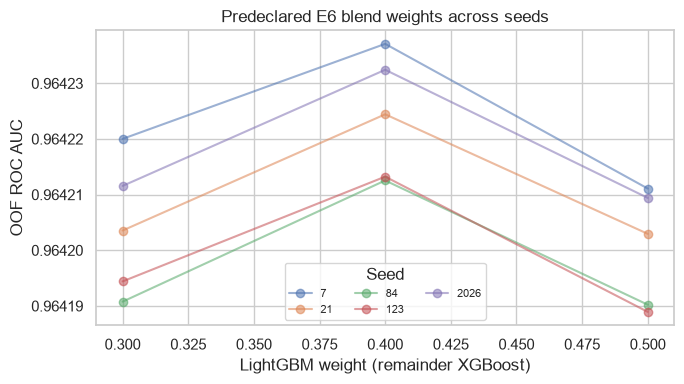

In [5]:
grid_summary = (grid.groupby("lightgbm_weight", as_index=False)
                .agg(mean_seed_auc=("oof_auc", "mean"), std_seed_auc=("oof_auc", "std"), mean_log_loss=("log_loss", "mean")))
display(grid_summary.style.format({"lightgbm_weight": "{:.1f}", "mean_seed_auc": "{:.6f}", "std_seed_auc": "{:.6f}", "mean_log_loss": "{:.6f}"}))

fig, ax = plt.subplots(figsize=(7, 4))
for seed, group in grid.groupby("fold_seed"):
    ax.plot(group["lightgbm_weight"], group["oof_auc"], marker="o", alpha=0.55, label=str(seed))
ax.set(title="Predeclared E6 blend weights across seeds", xlabel="LightGBM weight (remainder XGBoost)", ylabel="OOF ROC AUC")
ax.legend(title="Seed", ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

The 40/60 blend wins on every seed, but only by a mean +0.000020 over 30/70 and +0.000023 over 50/50. This consistent direction supports retaining 40/60, while the tiny scale confirms the earlier interpretation: the useful blend region is flat and the exact decimal weight should not be overinterpreted.

## Limitations and decision

Five seeds are a deliberately small confirmation sample. Bootstrap intervals from five values are discrete, and paired t intervals assume the seed differences are approximately normal. The 25 folds are dependent within their five seed assignments and are **not** treated as 25 independent experiments.

There is also a procedural nuance: the original seed-42 E6 OOF score came from fold-local early stopping, whose median best iterations became the deployed 3,808/4,720 round counts. E8 applies those fixed deployed counts to every new fold. The seed-42 comparison is therefore useful historical context, not a perfectly identical replicate.

**Decision.** E6 remains the defensible champion. Repeated validation strengthens the E4→E5→E6 progression and supports retaining the simple 40% LightGBM / 60% XGBoost blend. The experiment selects no new model, creates no submission, and preserves all negative and uncertainty findings.